# **1. Perkenalan Dataset**


## Deskripsi Dataset

Dataset yang digunakan adalah **Heart Disease Dataset** yang bersumber dari [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) dan merupakan turunan dari UCI Machine Learning Repository.

Dataset ini berisi informasi medis pasien yang digunakan untuk memprediksi apakah seseorang memiliki penyakit jantung atau tidak (klasifikasi biner).

### Informasi Dataset
- **Jumlah baris**: 1025 baris
- **Jumlah kolom**: 14 kolom
- **Target**: `target` (1 = ada penyakit jantung, 0 = tidak ada)

### Deskripsi Fitur
| Fitur | Deskripsi |
|---|---|
| age | Usia pasien |
| sex | Jenis kelamin (1 = pria, 0 = wanita) |
| cp | Tipe nyeri dada (0-3) |
| trestbps | Tekanan darah istirahat (mm Hg) |
| chol | Kolesterol serum (mg/dl) |
| fbs | Gula darah puasa > 120 mg/dl (1 = ya, 0 = tidak) |
| restecg | Hasil elektrokardiografi istirahat (0-2) |
| thalach | Detak jantung maksimum |
| exang | Angina akibat olahraga (1 = ya, 0 = tidak) |
| oldpeak | ST depression akibat olahraga |
| slope | Kemiringan segmen ST puncak (0-2) |
| ca | Jumlah pembuluh utama (0-3) |
| thal | Thalassemia (0-3) |
| target | Label target (1 = penyakit jantung, 0 = normal) |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Load dataset
df = pd.read_csv('heart.csv')
print('Shape dataset:', df.shape)
df.head()

Shape dataset: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
# Statistik deskriptif
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
# Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values ===
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []

Total missing values: 0


In [7]:
# Cek Duplikasi
print('=== Data Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== Data Duplikat ===
Jumlah baris duplikat: 723


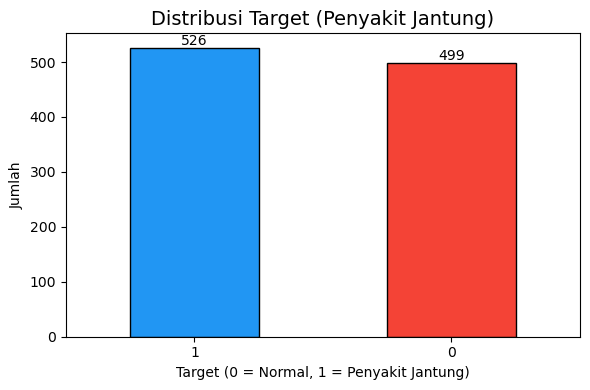

target
1    526
0    499
Name: count, dtype: int64


In [8]:
# Distribusi Target
plt.figure(figsize=(6, 4))
ax = df['target'].value_counts().plot(kind='bar', color=['#2196F3', '#F44336'], edgecolor='black')
plt.title('Distribusi Target (Penyakit Jantung)', fontsize=14)
plt.xlabel('Target (0 = Normal, 1 = Penyakit Jantung)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()
print(df['target'].value_counts())

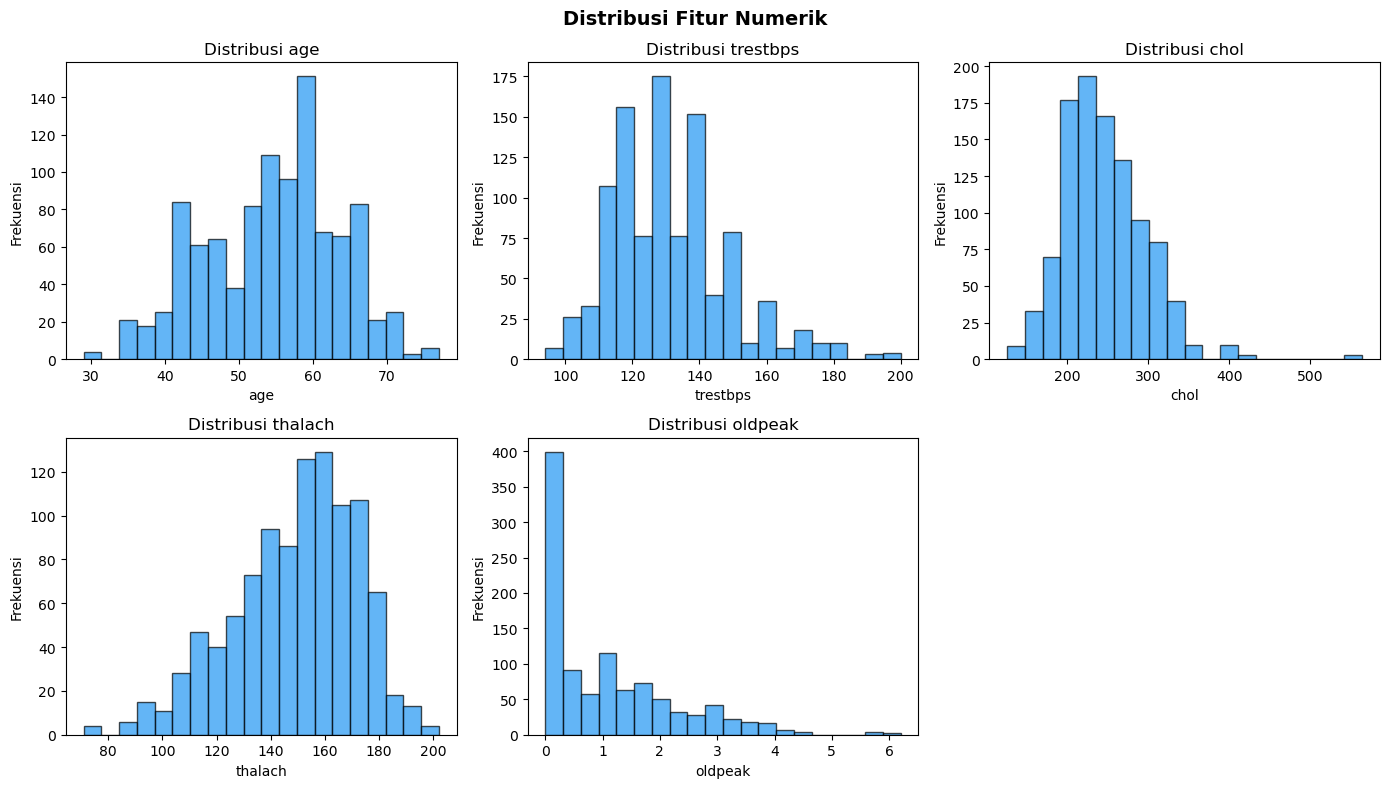

In [9]:
# Distribusi Fitur Numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='#2196F3', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

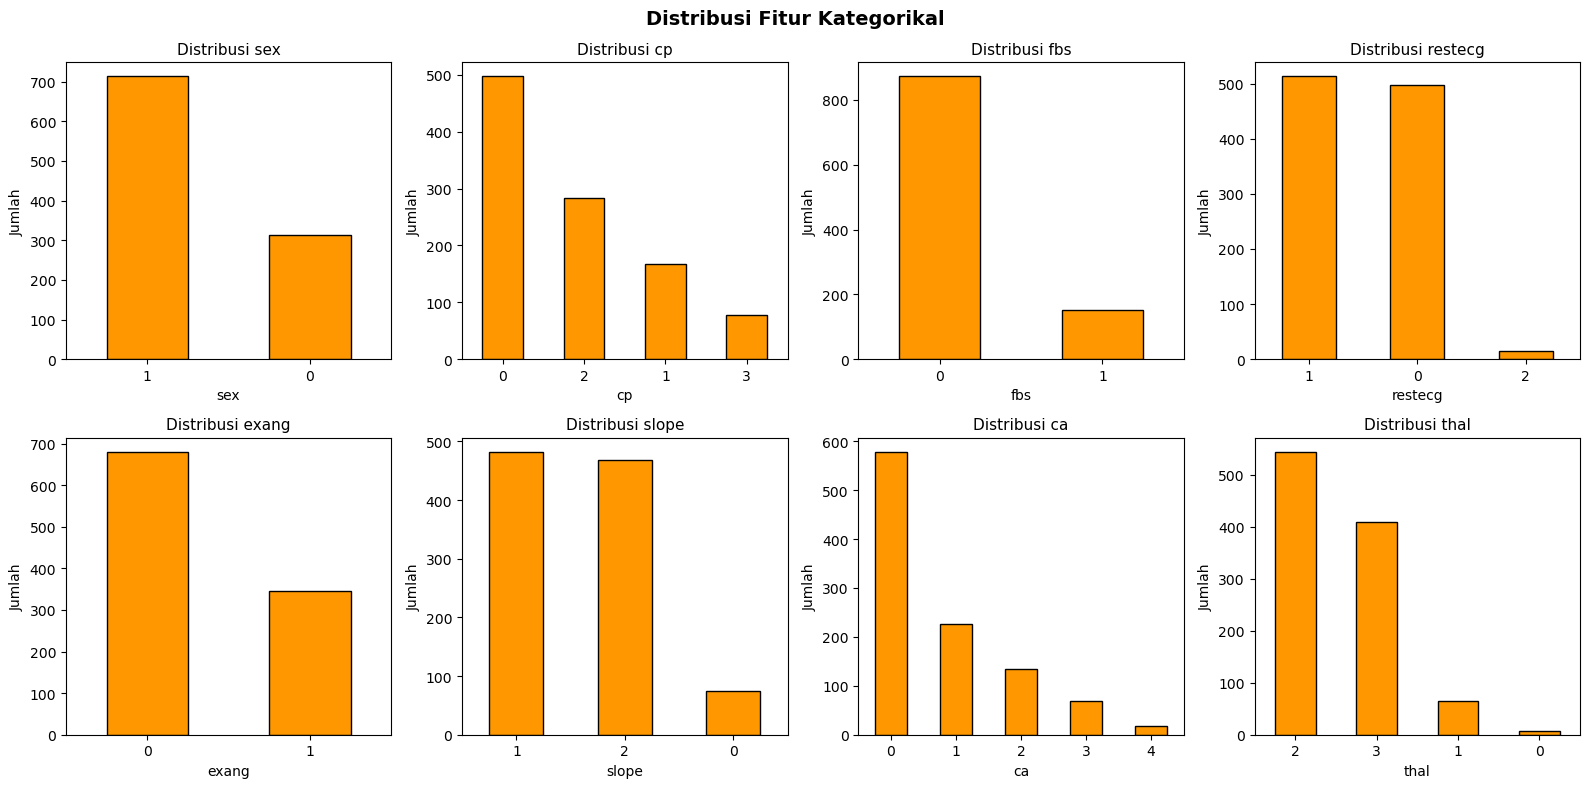

In [10]:
# Distribusi Fitur Kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='#FF9800', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

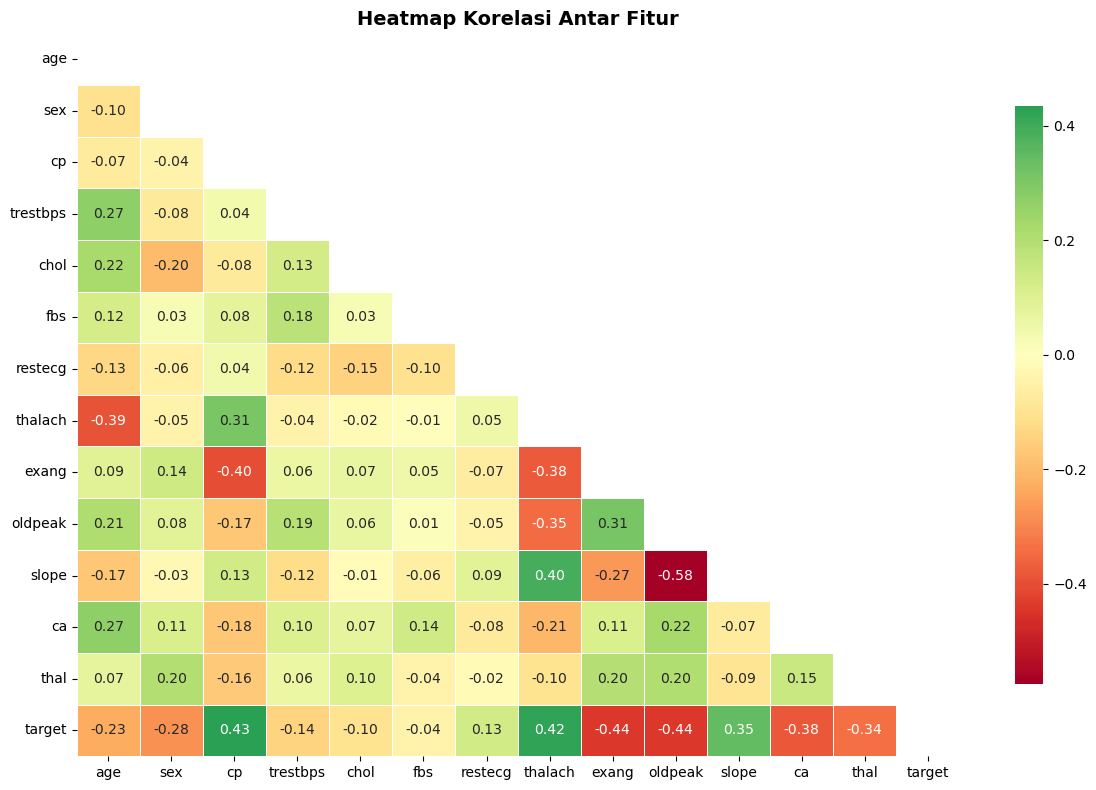

In [11]:
# Heatmap Korelasi
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

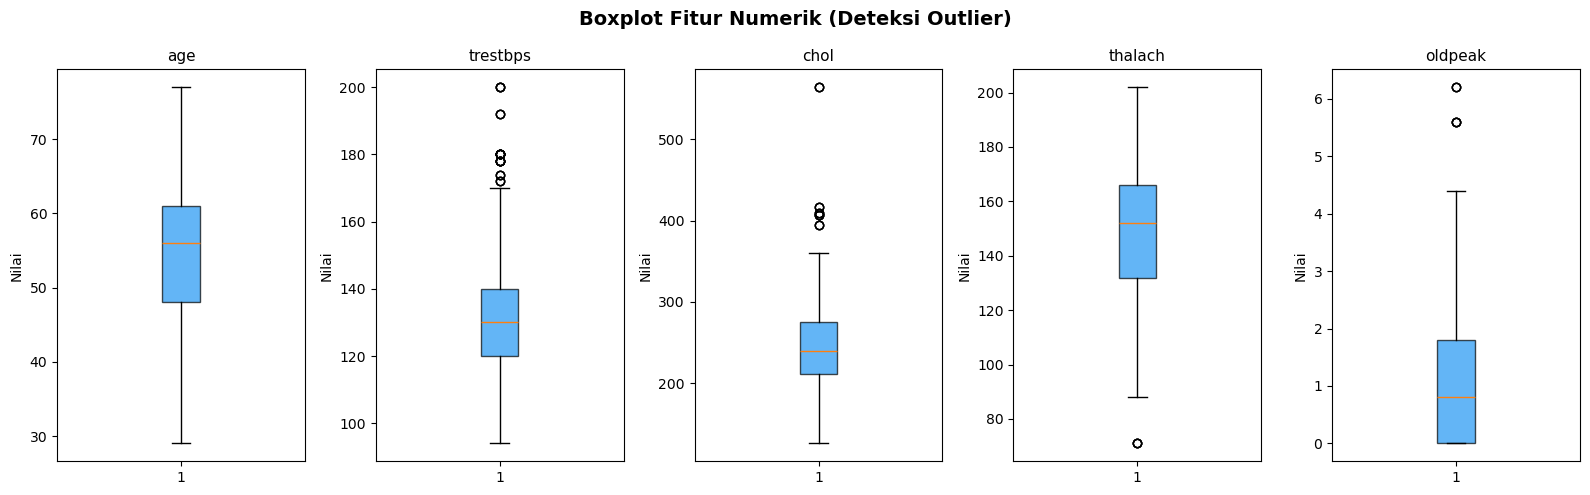

In [12]:
# Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#2196F3', alpha=0.7))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Nilai')

plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Kesimpulan EDA

Dari EDA yang dilakukan, diperoleh beberapa insight:
1. Dataset tidak memiliki missing values
2. Terdapat **baris duplikat** yang perlu dihapus
3. Distribusi target relatif **seimbang** (tidak perlu oversampling)
4. Terdapat **outlier** pada fitur `chol`, `trestbps`, dan `oldpeak`
5. Fitur `thalach` berkorelasi negatif dengan target, sedangkan `cp` berkorelasi positif
6. Fitur numerik memiliki skala berbeda → perlu **standarisasi**
7. Fitur seperti `cp`, `restecg`, `slope`, `thal` bersifat kategorikal ordinal → perlu **encoding**

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# Mulai dari salinan dataset
df_processed = df.copy()
print('Shape awal:', df_processed.shape)

Shape awal: (1025, 14)


In [14]:
# Menghapus Duplikat
before = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
after = df_processed.shape[0]
print(f'Baris sebelum drop duplikat : {before}')
print(f'Baris setelah drop duplikat  : {after}')
print(f'Duplikat dihapus             : {before - after}')

Baris sebelum drop duplikat : 1025
Baris setelah drop duplikat  : 302
Duplikat dihapus             : 723


In [15]:
# Penanganan Missing Values
print('Missing values setelah drop duplikat:')
print(df_processed.isnull().sum())

# Jika ada missing values pada kolom numerik, isi dengan median
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f'  Kolom {col}: diisi dengan median = {median_val}')

# Jika ada missing values pada kolom kategorikal, isi dengan modus
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)
        print(f'  Kolom {col}: diisi dengan modus = {mode_val}')

print('\nValidasi: semua missing values sudah ditangani.')

Missing values setelah drop duplikat:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Validasi: semua missing values sudah ditangani.


In [16]:
# Penanganan Outlier (IQR Method) pada fitur numerik
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = df_clean.shape[0]
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        after = df_clean.shape[0]
        print(f'  {col}: lower={lower:.2f}, upper={upper:.2f} | dihapus={before - after} baris')
    return df_clean

print('=== Penanganan Outlier (IQR) ===')
df_processed = remove_outliers_iqr(df_processed, numerical_cols)
print(f'\nShape setelah remove outlier: {df_processed.shape}')

=== Penanganan Outlier (IQR) ===
  age: lower=28.50, upper=80.50 | dihapus=0 baris
  trestbps: lower=90.00, upper=170.00 | dihapus=9 baris
  chol: lower=116.50, upper=368.50 | dihapus=5 baris
  thalach: lower=79.12, upper=220.12 | dihapus=1 baris
  oldpeak: lower=-2.40, upper=4.00 | dihapus=4 baris

Shape setelah remove outlier: (283, 14)


In [17]:
# Encoding Fitur Kategorikal (One-Hot Encoding untuk cp, restecg, slope, thal)
# Fitur yang memerlukan One-Hot Encoding (lebih dari 2 kategori, nominal)
ohe_cols = ['cp', 'restecg', 'slope', 'thal']

df_processed = pd.get_dummies(df_processed, columns=ohe_cols, drop_first=False)

print('Kolom setelah One-Hot Encoding:')
print(df_processed.columns.tolist())
print('\nShape:', df_processed.shape)

Kolom setelah One-Hot Encoding:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_0', 'thal_1', 'thal_2', 'thal_3']

Shape: (283, 24)


In [18]:
# Standarisasi Fitur Numerik
scaler = StandardScaler()

df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

print('=== Setelah Standarisasi ===')
print(df_processed[numerical_cols].describe().round(3))

=== Setelah Standarisasi ===
           age  trestbps     chol  thalach  oldpeak
count  283.000   283.000  283.000  283.000  283.000
mean    -0.000     0.000   -0.000   -0.000    0.000
std      1.002     1.002    1.002    1.002    1.002
min     -2.749    -2.336   -2.609   -2.735   -0.929
25%     -0.774    -0.643   -0.714   -0.727   -0.929
50%      0.104     0.008   -0.074    0.134   -0.343
75%      0.653     0.659    0.632    0.796    0.633
max      2.519     2.612    2.640    2.297    2.975


In [19]:
# Binning pada Fitur Age
age_original = df.loc[df_processed.index, 'age'] if hasattr(df_processed, 'index') else None

# Gunakan data age dari df sebelum scaling untuk binning
df_temp_age = df.copy().drop_duplicates()
df_temp_age = df_temp_age.loc[df_processed.index]

bins = [0, 40, 50, 60, 100]
labels = ['<40', '40-50', '50-60', '>60']
df_processed['age_group'] = pd.cut(df_temp_age['age'], bins=bins, labels=labels)

# Encode age_group
le = LabelEncoder()
df_processed['age_group'] = le.fit_transform(df_processed['age_group'].astype(str))

print('Distribusi age_group:')
print(df_processed['age_group'].value_counts())

Distribusi age_group:
age_group
1    119
0     76
3     70
2     18
Name: count, dtype: int64


In [20]:
# Konversi kolom boolean hasil OHE ke integer
bool_cols = df_processed.select_dtypes(include='bool').columns
df_processed[bool_cols] = df_processed[bool_cols].astype(int)

print('Tipe data akhir:')
print(df_processed.dtypes)
print('\nShape final:', df_processed.shape)
df_processed.head()

Tipe data akhir:
age          float64
sex            int64
trestbps     float64
chol         float64
fbs            int64
thalach      float64
exang          int64
oldpeak      float64
ca             int64
target         int64
cp_0           int64
cp_1           int64
cp_2           int64
cp_3           int64
restecg_0      int64
restecg_1      int64
restecg_2      int64
slope_0        int64
slope_1        int64
slope_2        int64
thal_0         int64
thal_1         int64
thal_2         int64
thal_3         int64
age_group      int64
dtype: object

Shape final: (283, 25)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3,age_group
0,-0.224919,1,-0.317917,-0.680075,0,0.796365,0,0.046903,2,0,...,1,0,0,0,1,0,0,0,1,1
1,-0.115174,1,0.658608,-0.881981,1,0.222452,1,2.096513,0,0,...,0,0,1,0,0,0,0,0,1,1
2,1.750489,1,0.984117,-1.532566,0,-1.101964,1,1.608511,0,0,...,1,0,1,0,0,0,0,0,1,3
3,0.762785,1,1.179422,-0.881981,0,0.487335,0,-0.929101,1,0,...,1,0,0,0,1,0,0,0,1,3
4,0.872530,0,0.528405,1.159512,1,-1.940760,0,0.925307,3,0,...,1,0,0,1,0,0,0,1,0,3


In [21]:
# Split Train/Test dan Simpan Dataset
import os

X = df_processed.drop('target', axis=1)
y = df_processed['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test : {y_test.shape}')

# Simpan hasil preprocessing
output_dir = 'heart_preprocessing'
os.makedirs(output_dir, exist_ok=True)

df_processed.to_csv(f'{output_dir}/heart_preprocessed.csv', index=False)
X_train.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test.to_csv(f'{output_dir}/X_test.csv', index=False)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)

print(f'\nDataset hasil preprocessing disimpan di folder: {output_dir}/')

X_train: (226, 24)
X_test : (57, 24)
y_train: (226,)
y_test : (57,)

Dataset hasil preprocessing disimpan di folder: heart_preprocessing/
